In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [62]:
df = pd.read_csv('merged_dataset.csv')
df.head()

,User-ID,ISBN,Rating,Title,Author,Year,Publisher,Age
0,276746,0425115801,0,Lightning,Dean R. Koontz,1996.0,Berkley Publishing Group,NaN
1,276746,0449006522,0,Manhattan Hunt Club,JOHN SAUL,2002.0,Ballantine Books,NaN
2,276746,0553561618,0,Dark Paradise,TAMI HOAG,1994.0,Bantam,NaN
3,276746,055356451X,0,Night Sins,TAMI HOAG,1995.0,Bantam,NaN
4,276746,0786014512,0,Make Them Cry,Kevin O'Brien,2002.0,Pinnacle Books,NaN


In [63]:
df = df.drop(columns=['User-ID', 'Age'])

Checking the dataset

In [64]:
print("Dataset shape")
print(df.shape)
print("\nFeature types")
print(df.dtypes)
print("\nNumber of missing features")
print(df.isna().sum())
print("\nDataset-sample")
print(df.head(3))

Dataset shape
(429205, 6)

Feature types
ISBN          object
Rating         int64
Title         object
Author        object
Year         float64
Publisher     object
dtype: object

Number of missing features
ISBN             0
Rating           0
Title        11722
Author       11722
Year         11722
Publisher    11722
dtype: int64

Dataset-sample
         ISBN  Rating                Title          Author    Year  \
0  0425115801       0            Lightning  Dean R. Koontz  1996.0   
1  0449006522       0  Manhattan Hunt Club       JOHN SAUL  2002.0   
2  0553561618       0        Dark Paradise       TAMI HOAG  1994.0   

                  Publisher  
0  Berkley Publishing Group  
1          Ballantine Books  
2                    Bantam  


Delete all missing data

In [65]:
df = df.dropna()
print(df.isna().sum())
print(f"Dataset shape after removing missing data: {df.shape}")

ISBN         0
Rating       0
Title        0
Author       0
Year         0
Publisher    0
dtype: int64
Dataset shape after removing missing data: (417483, 6)


Create a mean for the ratings

In [66]:
mean_ratings = df.groupby('ISBN').agg({
    'Rating': 'mean',
    'Title': 'first',
    'Author': 'first',
    'Year': 'first',
    'Publisher': 'first'
}).reset_index()
mean_ratings = mean_ratings.rename(columns={'Rating': 'Mean_Rating'})
print(mean_ratings.shape)
print(mean_ratings.head())

(14610, 6)
         ISBN  Mean_Rating                                            Title  \
0  0002005018     4.272727                                     Clara Callan   
1  0002251760     4.909091  The Forgetting Room: A Fiction (Byzantium Book)   
2  0006485200     3.500000                         The Piano Man's Daughter   
3  0007106572     0.785714                                 Guilty Creatures   
4  0007110928     3.458333                                            Billy   

                 Author    Year                    Publisher  
0  Richard Bruce Wright  2001.0        HarperFlamingo Canada  
1          Nick Bantock  1997.0                Harpercollins  
2       Timothy Findley  1999.0    Britnell Book Wholesalers  
3           Sue Welfare  2001.0                HarperCollins  
4     Pamela Stephenson  2002.0  HarperCollins Entertainment  


Delete duplicates

In [67]:
cleaned_df = mean_ratings.drop_duplicates(subset=['ISBN', 'Title', 'Author']).reset_index(drop=True)
print(f"Dataset shape after removing duplicates: {cleaned_df.shape}")
cleaned_df.to_csv('cleaned_dataset.csv', index=False)
print(cleaned_df.head(3))

Dataset shape after removing duplicates: (14610, 6)
         ISBN  Mean_Rating                                            Title  \
0  0002005018     4.272727                                     Clara Callan   
1  0002251760     4.909091  The Forgetting Room: A Fiction (Byzantium Book)   
2  0006485200     3.500000                         The Piano Man's Daughter   

                 Author    Year                  Publisher  
0  Richard Bruce Wright  2001.0      HarperFlamingo Canada  
1          Nick Bantock  1997.0              Harpercollins  
2       Timothy Findley  1999.0  Britnell Book Wholesalers  


TF-IDF Vector embedding

In [68]:
author_vec = TfidfVectorizer()
publisher_vec = TfidfVectorizer()

author_emb = author_vec.fit_transform(cleaned_df['Author'].astype(str))
publisher_emb = publisher_vec.fit_transform(cleaned_df['Publisher'].astype(str))


Sentence-transformer embedding

In [69]:
# %pip install sentence-transformers
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
title_emb = model.encode(cleaned_df['Title'].astype(str), show_progress_bar=True)
title_emb = np.array(title_emb)
print(f"Title embedding shape: {title_emb.shape}")

Batches: 100%|██████████| 457/457 [00:21<00:00, 20.84it/s]


Title embedding shape: (14610, 384)


In [70]:
numeric = cleaned_df[['Mean_Rating', 'Year']].values
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric)

from scipy.sparse import csr_matrix
title_sparse = csr_matrix(title_emb)
X = hstack([title_sparse, author_emb, publisher_emb, numeric_scaled])
print("Final embedding shape:", X.shape)

Final embedding shape: (14610, 5467)


PCA for dimensionality reduction

In [86]:
pca = PCA(n_components=2)
X_dense = X.toarray()
reduced_X = pd.DataFrame(data=pca.fit_transform(X_dense), columns=['PCA1', 'PCA2'])
reduced_X.head() 

,PCA1,PCA2
0,-0.408927,1.572923
1,-1.209503,1.590846
2,-0.197264,0.905067
3,1.518148,-0.579433
4,0.149900,1.164205


Elbow Method

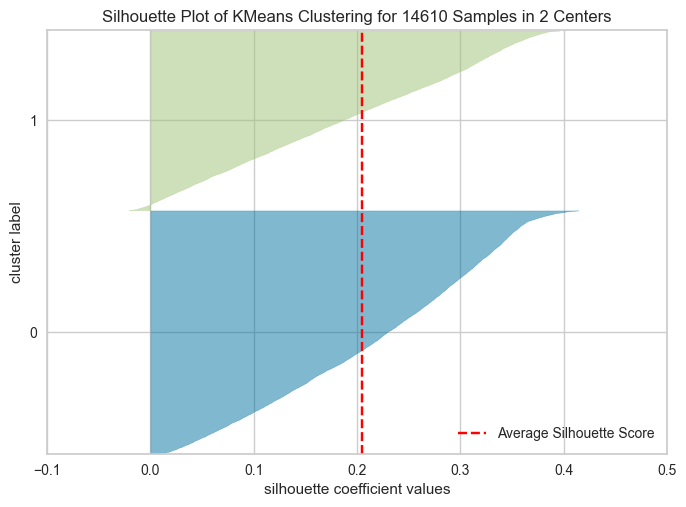

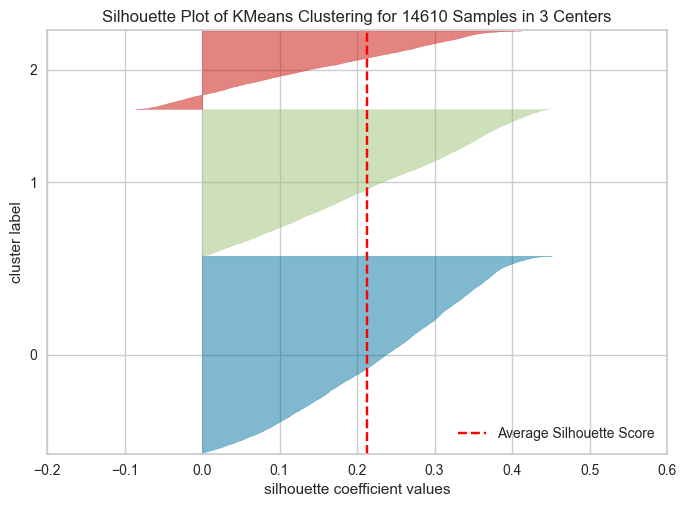

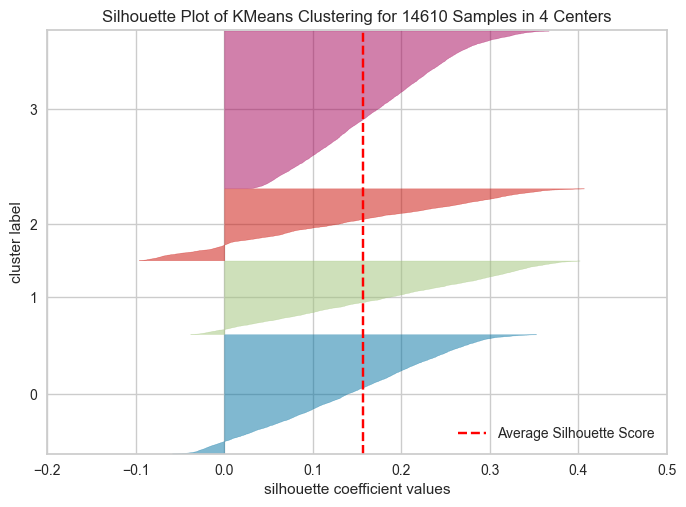

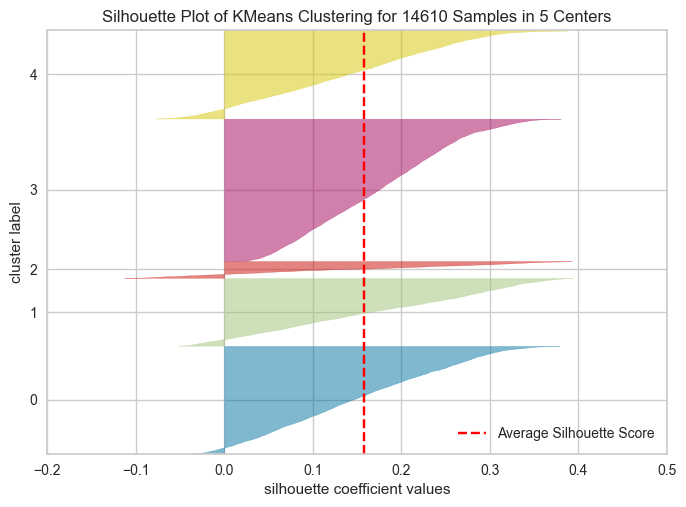

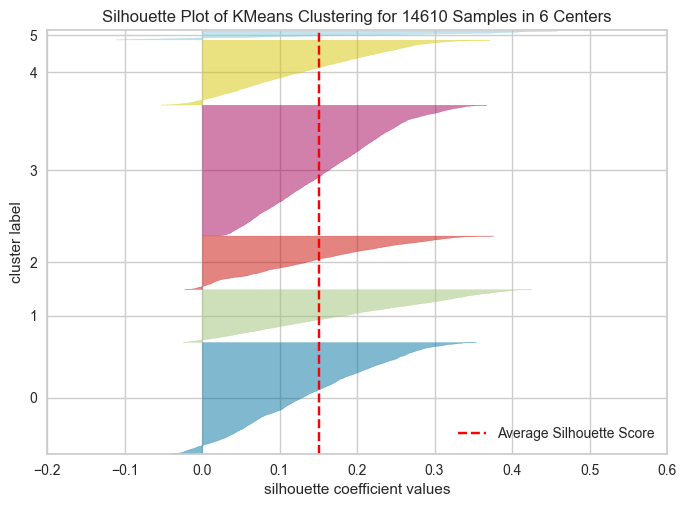

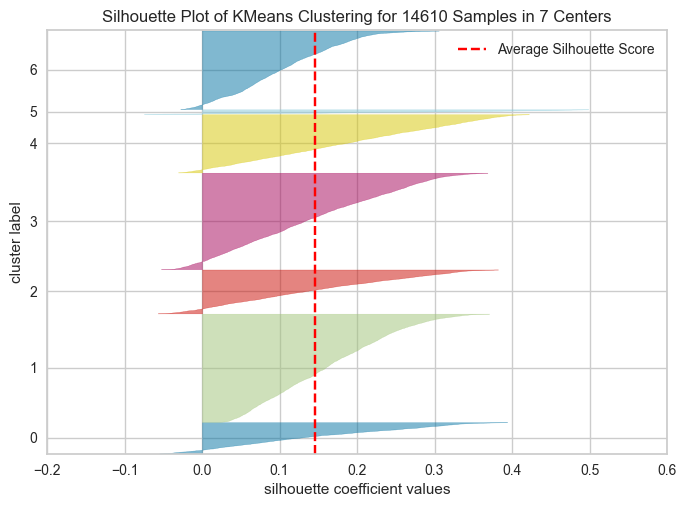

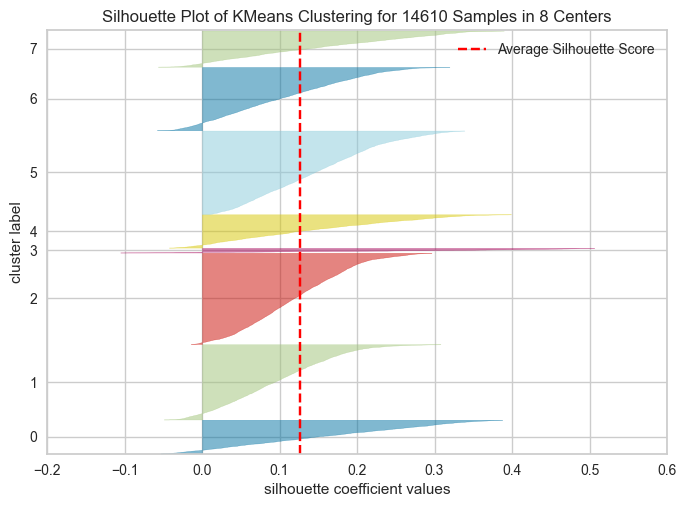

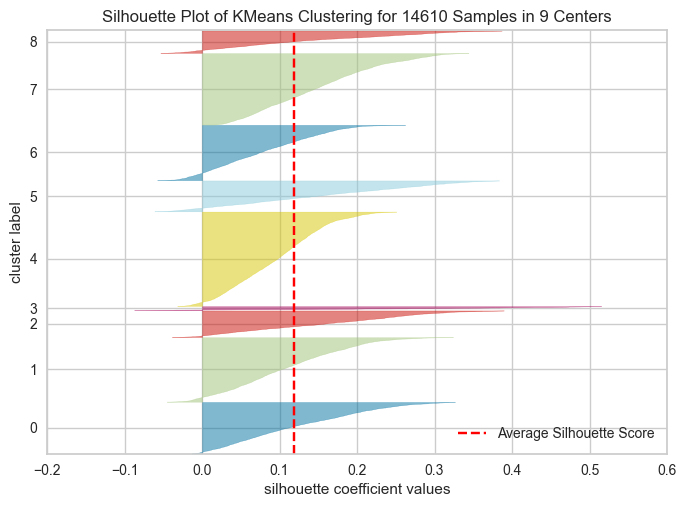

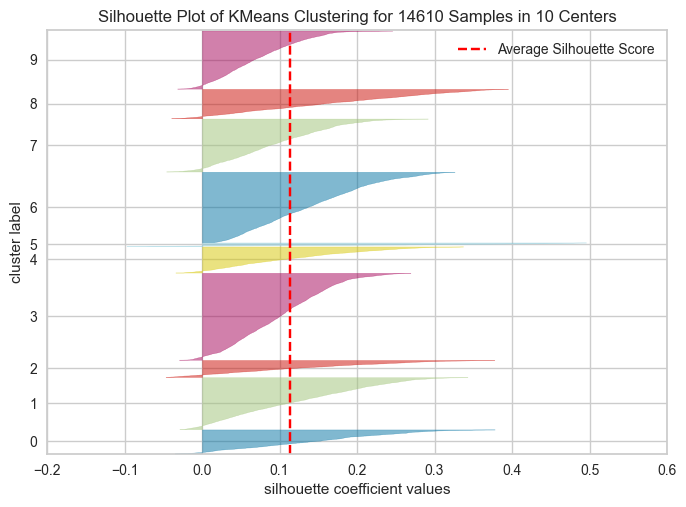

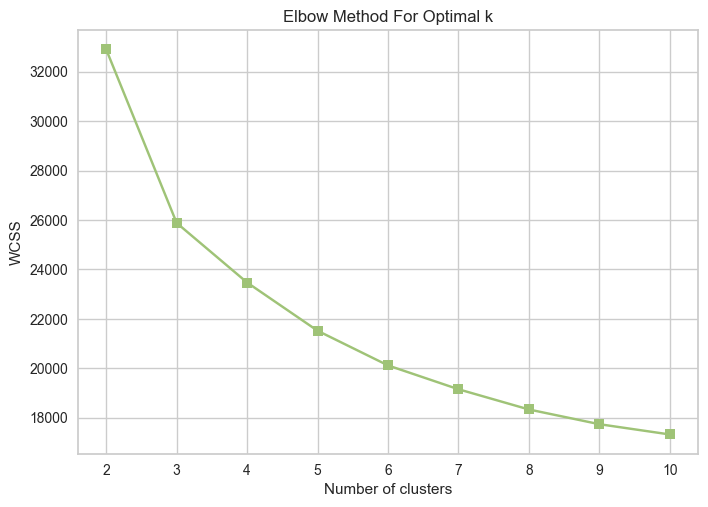

In [82]:
wcss = {}
min_clusters = 2
max_clusters = 11
for i in range(min_clusters, max_clusters):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    # kmeans.fit(X)
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
    visualizer.fit(reduced_X)
    visualizer.show()
    wcss[i] = kmeans.inertia_
plt.plot(wcss.keys(), wcss.values(), 'gs-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k')
plt.show()

Plotting the clusters

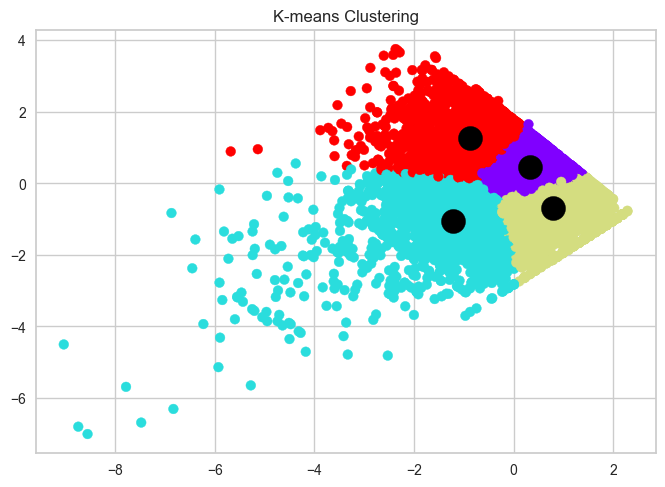

In [87]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(reduced_X)
plt.scatter(reduced_X['PCA1'], reduced_X['PCA2'], c=kmeans.labels_, cmap='rainbow')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='black',)
plt.title('K-means Clustering')
plt.show()